# 4. Correcting and evaluating

Plates drift, well position matters, and cell count affects most features. This page removes
those artifacts and measures whether removing them helped.

Every correction here can make results worse on a given dataset. The last section shows a
real case where sphering, a standard step of the pipeline, cuts mechanism retrieval by seventy
percent.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc

import mantispy as mt

## Position effects

Edge wells evaporate, corners sit at a different temperature, and dispensing drifts along a
row. `correct_plate_position` fits Tukey's median polish to the row and column effects of
each plate and subtracts them. Median polish is used instead of a mean-based fit so that a few
extreme wells do not define the gradient.

In [2]:
from mantispy._core.plate import well_row

cells = mt.ds.synthetic_plate(
    n_plates=2,
    n_wells=96,
    n_cells=20,
    n_features=30,
    row_gradient=3.0,
    col_gradient=2.0,
    seed=0,
)
wells = mt.tl.aggregate(cells)

rows = np.array([well_row(w) for w in wells.obs["Metadata_Well"]])
before = abs(np.corrcoef(rows, wells.X[:, 0])[0, 1])

mt.pp.correct_plate_position(wells)
after = abs(np.corrcoef(rows, wells.X[:, 0])[0, 1])
{"correlation with plate row, before": round(float(before), 3), "after": round(float(after), 3)}

{'correlation with plate row, before': 0.744, 'after': 0.016}

If treatments are laid out by column, fit the effects on the controls only, with
`reference="negcon"`, so that treatment effects are not absorbed into a column effect and
subtracted.

This has a limit. A median polish can only fit a column effect for columns that contain
reference rows, and most layouts put the controls in a few fixed columns, such as 1 and 2 or
23 and 24. With controls in four of twenty-four columns there is no control-only column effect
to fit. Row effects still work, because controls in an edge column span every row. For column
effects on a column-wise layout, the design has confounded the effect you want to correct, and
the fix is a randomized layout on the next plate.

## Confounders

Cell count is the most common one: a sparse well looks different from a confluent one
regardless of treatment. `regress_out` fits each feature against the confounder within each
plate and keeps the residual.

In [3]:
confounded = mt.ds.synthetic_plate(n_wells=96, n_cells=30, n_features=20, confounder_effect=3.0, seed=0)
profiles = mt.tl.aggregate(confounded, min_cells=0)
feature = profiles.uns["mantispy"]["truth"]["confounded_features"][0]
position = profiles.var_names.get_loc(feature)
counts = profiles.obs["Metadata_CellCount"].to_numpy(dtype=float)

before = abs(np.corrcoef(counts, profiles.X[:, position])[0, 1])
mt.pp.regress_out(profiles, keys=("Metadata_CellCount",), by=None)
after = abs(np.corrcoef(counts, profiles.X[:, position])[0, 1])
{"correlation with cell count, before": round(float(before), 3), "after": round(float(after), 3)}

{'correlation with cell count, before': 0.985, 'after': 0.0}

Missing values stay missing. Imputing them for the regression and writing the fitted value
back would make an unmeasured value look like a real measurement.

## Sphering

Sphering is typical variation normalization. The covariance of the negative controls
describes variation that is not of interest, and whitening removes it, leaving the variation
caused by the perturbations.

`ZCA-cor` is the default because it rotates back into the original feature basis, so the
columns still match `var`. `PCA` and `PCA-cor` return principal components instead and warn
when they overwrite `X`, because `var` then no longer describes the columns.

Sphering needs more control wells than features. With fewer, the control covariance is
singular, the null directions are padded, and the transform amplifies noise. `sphere` warns
when that happens, and the last section shows the cost.

## Measuring the result

`mt.metrics` scores a representation with several metrics. Batch-mixing metrics and
biological-signal metrics trade off against each other, and a correction that improves one
at the expense of the other has not helped.

In [4]:
batched = mt.ds.synthetic_plate(
    n_plates=4,
    n_wells=96,
    n_cells=10,
    n_features=30,
    n_batches=2,
    batch_effect=4.0,
    n_perturbations=5,
    effect_size=3.0,
    seed=0,
)
batched = mt.tl.aggregate(batched, min_cells=0)
sc.pp.pca(batched, n_comps=15)

corrected = batched.copy()
mt.pp.normalize(corrected, method="standardize", by="Metadata_Batch")
sc.pp.pca(corrected, n_comps=15)
batched.obsm["X_batch_centred"] = corrected.obsm["X_pca"]

table = mt.metrics.evaluate_correction(
    batched,
    reps=("X_pca", "X_batch_centred"),
    label_key="Metadata_Perturbation",
    batch_key="Metadata_Batch",
)
table

,metric,representation,key,value,better
0,silhouette_label,X_pca,Metadata_Perturbation,5.682465e-01,higher
1,silhouette_batch,X_pca,Metadata_Batch,7.278925e-02,higher
2,ilisi,X_pca,Metadata_Batch,1.000000e+00,higher
3,clisi,X_pca,Metadata_Perturbation,1.009925e+00,lower
4,pc_regression,X_pca,Metadata_Batch,8.735887e-01,lower
5,silhouette_label,X_batch_centred,Metadata_Perturbation,6.665337e-01,higher
6,silhouette_batch,X_batch_centred,Metadata_Batch,9.599711e-01,higher
7,ilisi,X_batch_centred,Metadata_Batch,1.953133e+00,higher
8,clisi,X_batch_centred,Metadata_Perturbation,1.026559e+00,lower
9,pc_regression,X_batch_centred,Metadata_Batch,1.104450e-14,lower


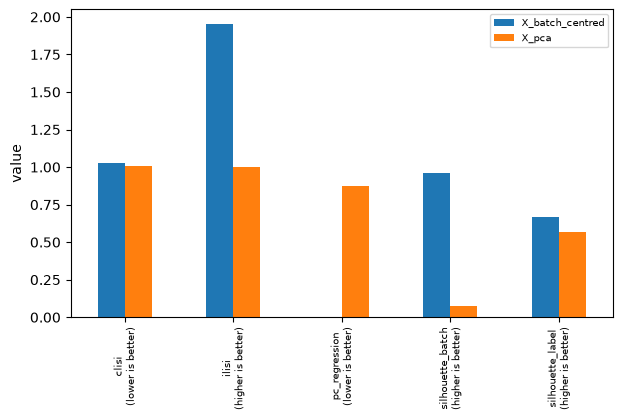

In [5]:
mt.pl.metrics(table)
plt.show()

Check the `better` column: two of the five metrics are better when lower. `pc_regression` is
the share of variance explained by batch, so centering each batch should lower it, and it
does.

`pl.batch_variance` shows the same per component, which tells you where in the embedding the
batch effect sits.

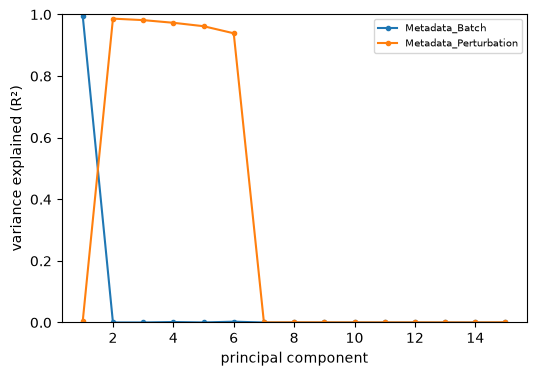

In [6]:
mt.pl.batch_variance(batched, keys=["Metadata_Batch", "Metadata_Perturbation"], use_rep="X_pca")
plt.show()

### A note on Harmony

Harmony is the usual recommendation for batch correction, and mantispy wraps it as
`pp.harmony`. It is the last step of the
[JUMP profiling recipe](https://github.com/broadinstitute/jump-profiling-recipe) for compound and ORF profiles, and with
Seurat RPCA it ranked in the top three in every scenario of {cite:t}`Arevalo_2024`. It corrects an embedding rather than the feature matrix, so run
`sc.pp.pca` first. It needs the optional extra: `pip install 'mantispy[harmony]'`.

`harmonypy` can report convergence and return the embedding unchanged. `pp.harmony` compares
its output with its input and warns when they are identical, since the pipeline would
otherwise continue with uncorrected numbers that look plausible.

[Tutorial 9](09_scaling_and_sites.ipynb) runs it on two-source JUMP data and measures the
result, including a case where a batch metric disagrees with retrieval. For a correction on
the features instead of an embedding, `sc.pp.combat` is the usual choice.

## Is a perturbation doing anything?

Mean average precision (mAP) asks a retrieval question: when profiles are ranked by
similarity to one profile, do its replicates rank above the profiles that should not match? It
is rank-based, so it needs no correlation threshold, and its permutation null gives every
group a p-value.

`tl.map` wraps [copairs](https://github.com/cytomining/copairs) {cite:p}`Kalinin_2025`, the Broad's implementation,
so the numbers are comparable with published ones.

Compare mAP with its null, not with an intuition about scores between zero and one. Unlike
accuracy, it has no fixed chance level: a random ranking's score depends on how many positives
each query has, so 0.14 can be a strong result on one screen and noise on another. `null_size`
and the `corrected_p_value` column account for this.

In [7]:
strong = mt.ds.synthetic_plate(
    n_plates=2,
    n_wells=96,
    n_cells=20,
    n_features=40,
    n_perturbations=5,
    effect_size=4.0,
    seed=0,
)
mt.pp.normalize(strong, by="Metadata_Plate", reference="negcon")
strong = mt.tl.aggregate(strong)

mt.tl.map(strong, mode="activity", null_size=1000)
strong.uns["mantispy"]["map"][["Metadata_Perturbation", "mean_average_precision", "corrected_p_value"]]

,Metadata_Perturbation,mean_average_precision,corrected_p_value
0,pert00,1.0,0.000999
1,pert01,1.0,0.000999
2,pert02,1.0,0.000999
3,pert03,1.0,0.000999
4,pert04,1.0,0.000999


Every perturbation scores 1.0, because with an effect size of 4.0 these five are easy to
retrieve. There is no DMSO row: in `mode="activity"` the negative controls are the reference
set every treatment is scored against, so they are not scored themselves.

`mode="cross_plate"` asks a stricter question: replicates must retrieve each other across
plates, which separates reproducible biology from a plate that happened to look uniform.

`percent_replicating` and `grit` are older readouts, kept because many published numbers use
them.

## A real screen: BBBC021

The sections above used synthetic data with known answers. BBBC021 is a real screen (MCF-7
cells, 38 compounds, 12 mechanisms of action), and its benchmark from {cite:t}`Ljosa_2013` is
still the standard one. This downloads about 10 MB.

### Degenerate features

`pp.normalize` flags `var["degenerate_scale"]`: features with no spread among the rows it
was fitted on. A feature can vary across a plate and still be constant among the few control
wells. `mad_robustize` then divides it by `epsilon = 1e-18` instead of by zero, as
pycytominer {cite:p}`Serrano_2025` does, so it comes back at around 1e17 and dominates every distance computed
afterwards. Feature selection does not catch it, because it measures variance across all
wells.

BBBC021 has two such features. Dropping them adds eight points to the final score below.


In [8]:
bbbc = mt.ds.bbbc021()
bbbc

/Users/tim.treis/Documents/GitHub/mantispy/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AnnData object with n_obs × n_vars = 632 × 473
    obs: 'Metadata_Plate', 'Metadata_Well', 'Metadata_Compound', 'Metadata_Concentration', 'Metadata_MOA', 'Metadata_Control', 'Metadata_Perturbation'
    var: 'object', 'feature_group', 'feature', 'channel', 'scale', 'angle', 'gray_levels', 'radial_bin', 'params', 'is_feature'
    uns: 'mantispy'
    layers: None (.X)

In [9]:
mt.pp.normalize(bbbc, method="mad_robustize", by="Metadata_Plate", reference="negcon")
# Two features have no spread among the DMSO wells; mad_robustize divides those by
# epsilon rather than by zero and returns them at ~1e17. See the note above.
bbbc = bbbc[:, ~bbbc.var["degenerate_scale"].to_numpy()].copy()
mt.pp.feature_select(bbbc)
bbbc = mt.pp.subset_features(bbbc)

treated = bbbc[~bbbc.obs["Metadata_Control"].to_numpy()].copy()
treated.obs["Metadata_Treatment"] = (
    treated.obs["Metadata_Compound"].astype(str) + "@" + treated.obs["Metadata_Concentration"].astype(str)
)
consensus = mt.tl.aggregate(treated, by=("Metadata_Treatment",), min_cells=0)
consensus.n_obs, consensus.obs["Metadata_MOA"].nunique()

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_30438/1399167850.py:1: UserWarning: 2 of 473 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Adding epsilon=1e-18 to their scale multiplies them by up to 1e18, so they dominate every distance downstream. They are flagged in var['degenerate_scale']; drop them with adata = adata[:, ~adata.var['degenerate_scale']].copy(). Feature selection does not catch a feature that varies across a plate but is constant among its control wells.
  mt.pp.normalize(bbbc, method="mad_robustize", by="Metadata_Plate", reference="negcon")


(103, 12)

103 treatments across 12 mechanisms, the same shape as the published benchmark.

The benchmark uses the not-same-compound rule: a treatment's nearest neighbor among
treatments of a different compound should share its mechanism. Excluding the same compound
prevents the task from being solved by matching a compound to itself at another dose.

In [10]:
def not_same_compound_accuracy(profiles):
    """Fraction of treatments whose nearest different-compound neighbour shares its MOA."""
    mt.tl.similarity(profiles, metric="cosine")
    similarity = np.asarray(profiles.obsp["similarity"]).copy()
    np.fill_diagonal(similarity, -np.inf)
    compound = profiles.obs["Metadata_Compound"].astype(str).to_numpy()
    moa = profiles.obs["Metadata_MOA"].astype(str).to_numpy()
    similarity[compound[:, None] == compound[None, :]] = -np.inf
    return float((moa[similarity.argmax(axis=1)] == moa).mean())


largest_class = consensus.obs["Metadata_MOA"].value_counts(normalize=True).iloc[0]
f"{not_same_compound_accuracy(consensus):.1%}, against {largest_class:.1%} for always guessing the largest class"

'77.7%, against 13.6% for always guessing the largest class'

Which mechanisms are resolved?

In [11]:
mt.tl.map(
    consensus,
    pos_sameby=["Metadata_MOA"],
    pos_diffby=["Metadata_Compound"],
    neg_diffby=["Metadata_MOA"],
    null_size=1000,
)
consensus.uns["mantispy"]["map"][["Metadata_MOA", "mean_average_precision", "below_corrected_p"]].sort_values(
    "mean_average_precision", ascending=False
)

,Metadata_MOA,mean_average_precision,below_corrected_p
11,Protein synthesis,1.000000,True
7,Kinase inhibitors,0.961905,True
1,Aurora kinase inhibitors,0.947214,True
2,Cholesterol-lowering,0.870833,True
9,Microtubule stabilizers,0.755501,True
6,Epithelial,0.741124,True
3,DNA damage,0.657428,True
4,DNA replication,0.608314,True
8,Microtubule destabilizers,0.566140,True
5,Eg5 inhibitors,0.526462,True


Rank by the mAP column rather than the significance column. Protein synthesis, kinase and
aurora kinase inhibitors separate cleanly; actin disruptors and protein degradation barely
do, which matches the literature on this dataset.

`below_corrected_p` is `True` for all twelve, including the lowest. With 103 treatments the
permutation null is tight enough that every mechanism differs from a random one, which does
not mean it is resolved. Rank by the statistic and use the q-value only to discard, as
[tutorial 5](05_hits_and_effects.ipynb) also recommends for cell-level hit calling.

### Where sphering makes things worse

Sphering is a standard step in the Broad recipe, but it hurts on this dataset. The shapes
show why: BBBC021 has 330 DMSO wells against 344 selected features, so the control covariance
is singular.

In [12]:
import warnings

sphered = mt.ds.bbbc021()
mt.pp.normalize(sphered, method="mad_robustize", by="Metadata_Plate", reference="negcon")
sphered = sphered[:, ~sphered.var["degenerate_scale"].to_numpy()].copy()
mt.pp.feature_select(sphered)
sphered = mt.pp.subset_features(sphered)

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    mt.pp.sphere(sphered, method="ZCA-cor", reference="negcon")
print(caught[0].message)

sphering is fitted on 330 reference rows for 344 features. With fewer rows than features the covariance is singular and the transform amplifies noise (on BBBC021 it lowered not-same-compound MOA retrieval from 78% to 22%). Select fewer features first, or use more controls.


/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_30438/1820249966.py:4: UserWarning: 2 of 473 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Adding epsilon=1e-18 to their scale multiplies them by up to 1e18, so they dominate every distance downstream. They are flagged in var['degenerate_scale']; drop them with adata = adata[:, ~adata.var['degenerate_scale']].copy(). Feature selection does not catch a feature that varies across a plate but is constant among its control wells.
  mt.pp.normalize(sphered, method="mad_robustize", by="Metadata_Plate", reference="negcon")


In [13]:
treated_sphered = sphered[~sphered.obs["Metadata_Control"].to_numpy()].copy()
treated_sphered.obs["Metadata_Treatment"] = (
    treated_sphered.obs["Metadata_Compound"].astype(str)
    + "@"
    + treated_sphered.obs["Metadata_Concentration"].astype(str)
)
consensus_sphered = mt.tl.aggregate(treated_sphered, by=("Metadata_Treatment",), min_cells=0)

{
    "without sphering": f"{not_same_compound_accuracy(consensus):.1%}",
    "with sphering": f"{not_same_compound_accuracy(consensus_sphered):.1%}",
}

{'without sphering': '77.7%', 'with sphering': '22.3%'}

Sphering cuts not-same-compound accuracy from 77.7% to 22.3%, a loss of seventy percent.

mantispy's sphering matches pycytominer's to seven significant figures on this data, so
pycytominer shows the same drop. The method does not suit this dataset, which is why
corrections should be measured with `evaluate_correction` instead of applied as a fixed
recipe.

Run the pipeline both ways and compare. For this dataset, either select fewer features so the
control matrix is well determined, or skip sphering.

## The whole pipeline in eleven calls

```python
import mantispy as mt

adata = mt.io.read_profiles("cp_output/", platemap="platemap.csv")
mt.pp.annotate_controls(adata, negcon=("DMSO",))
mt.pp.calculate_qc_metrics(adata)
mt.pp.image_qc(adata)
mt.pp.filter_images(adata)
mt.pp.filter_cells(adata)
mt.pp.normalize(adata, by="Metadata_Plate", reference="negcon")
wells = mt.tl.aggregate(adata)
mt.pp.feature_select(wells)
wells = mt.pp.subset_features(wells)
mt.tl.map(wells, mode="activity")
```